# Multi-Battery Validation & Explainable AI

## NASA Li-ion Battery Prognostics

This notebook extends the battery intelligence framework from single-cell and two-cell experiments toward multi-battery validation and explainable machine learning.

### Objectives

1. Expand the analysis to additional NASA Li-ion ageing cells.
2. Validate discharge-cycle indexing and SOH reconstruction across all cells.
3. Compare battery-to-battery degradation trajectories and EOL behaviour.
4. Develop multi-cell SOH and RUL modelling datasets using leakage-safe causal features.
5. Perform leave-one-battery-out validation.
6. Quantify cross-cell generalization and target-range extrapolation.
7. Identify failure modes caused by cell-specific degradation regimes.
8. Apply SHAP-based explainability to validated predictive models.
9. Distinguish global feature importance from battery-specific model behaviour.
10. Identify conditions under which model explanations or predictions should be treated as low-confidence.

### Validation principles

- `cycle` represents sequential discharge-cycle count.
- `record_index` is retained only for source-data traceability.
- Future observations are never used to construct predictive features.
- Cell identity is used for grouping and evaluation, not as a shortcut predictor.
- Train/test separation is performed at the battery level whenever evaluating cross-cell generalization.
- EOL is defined as the first measured discharge cycle at or below 80% SOH.
- RUL is measured in remaining discharge cycles until the battery-specific EOL threshold.
- Hyperparameters must not be tuned using the held-out battery.
- SHAP explanations are interpreted only in the context of validated model performance.
- Conclusions are limited to the NASA cells actually evaluated.

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "raw"
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from nasa_loader import load_nasa_battery
from battery_features import (
    add_soh_features,
    add_degradation_features,
)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")
print(f"Source directory: {SRC_DIR}")

Project root: C:\Users\Drago\Battery-Analytics-Portfolio
Data directory: C:\Users\Drago\Battery-Analytics-Portfolio\data\raw
Source directory: C:\Users\Drago\Battery-Analytics-Portfolio\src


In [2]:
battery_files = {
    "B0005": DATA_DIR / "B0005.mat",
    "B0006": DATA_DIR / "B0006.mat",
    "B0007": DATA_DIR / "B0007.mat",
    "B0018": DATA_DIR / "B0018.mat",
}

batteries = {}

for battery_name, file_path in battery_files.items():

    df = load_nasa_battery(
        file_path,
        battery_name,
    )

    df = add_soh_features(df)
    df = add_degradation_features(df)

    # Validate corrected discharge-cycle indexing
    assert df["cycle"].equals(
        df["discharge_cycle"]
    )

    assert df["cycle"].iloc[0] == 1

    assert df["cycle"].iloc[-1] == len(df)

    batteries[battery_name] = df


for battery_name, df in batteries.items():

    print(
        f"{battery_name}: "
        f"{len(df)} discharge cycles | "
        f"Initial capacity = "
        f"{df['capacity_Ah'].iloc[0]:.4f} Ah | "
        f"Final capacity = "
        f"{df['capacity_Ah'].iloc[-1]:.4f} Ah | "
        f"Final SOH = "
        f"{df['SOH_percent'].iloc[-1]:.2f}%"
    )

B0005: 168 discharge cycles | Initial capacity = 1.8565 Ah | Final capacity = 1.3251 Ah | Final SOH = 71.38%
B0006: 168 discharge cycles | Initial capacity = 2.0353 Ah | Final capacity = 1.1857 Ah | Final SOH = 58.25%
B0007: 168 discharge cycles | Initial capacity = 1.8911 Ah | Final capacity = 1.4325 Ah | Final SOH = 75.75%
B0018: 132 discharge cycles | Initial capacity = 1.8550 Ah | Final capacity = 1.3411 Ah | Final SOH = 72.29%


In [3]:
# ---------------------------------------------------------
# Battery-specific EOL analysis
# ---------------------------------------------------------

EOL_THRESHOLD = 80.0


def get_eol_information(
    df,
    threshold=EOL_THRESHOLD,
):
    """
    Return the first measured discharge cycle
    at or below the specified SOH threshold.
    """

    eol_rows = df.loc[
        df["SOH_percent"] <= threshold
    ]

    if eol_rows.empty:
        return {
            "EOL_cycle": np.nan,
            "SOH_at_EOL": np.nan,
            "capacity_at_EOL_Ah": np.nan,
        }

    first_eol = eol_rows.iloc[0]

    return {
        "EOL_cycle":
            int(first_eol["cycle"]),

        "SOH_at_EOL":
            float(first_eol["SOH_percent"]),

        "capacity_at_EOL_Ah":
            float(first_eol["capacity_Ah"]),
    }


battery_summary_records = []

for battery_name, df in batteries.items():

    eol_info = get_eol_information(
        df,
        threshold=EOL_THRESHOLD,
    )

    battery_summary_records.append(
        {
            "battery": battery_name,
            "discharge_cycles": len(df),

            "initial_capacity_Ah":
                df["capacity_Ah"].iloc[0],

            "final_capacity_Ah":
                df["capacity_Ah"].iloc[-1],

            "final_SOH_percent":
                df["SOH_percent"].iloc[-1],

            "EOL_cycle":
                eol_info["EOL_cycle"],

            "SOH_at_EOL":
                eol_info["SOH_at_EOL"],

            "capacity_at_EOL_Ah":
                eol_info[
                    "capacity_at_EOL_Ah"
                ],
        }
    )


battery_summary = pd.DataFrame(
    battery_summary_records
)

display(
    battery_summary.round(4)
)

,battery,discharge_cycles,initial_capacity_Ah,final_capacity_Ah,final_SOH_percent,EOL_cycle,SOH_at_EOL,capacity_at_EOL_Ah
0,B0005,168,1.8565,1.3251,71.3756,101,79.7427,1.4804
1,B0006,168,2.0353,1.1857,58.2545,61,79.0458,1.6088
2,B0007,168,1.8911,1.4325,75.7491,124,79.7326,1.5078
3,B0018,132,1.8550,1.3411,72.2937,75,79.9634,1.4833


In [4]:
# ---------------------------------------------------------
# Validate EOL threshold crossing
# ---------------------------------------------------------

for battery_name, df in batteries.items():

    eol_cycle = battery_summary.loc[
        battery_summary["battery"]
        == battery_name,
        "EOL_cycle",
    ].iloc[0]

    if pd.isna(eol_cycle):

        print(
            f"{battery_name}: "
            f"No {EOL_THRESHOLD:.0f}% SOH crossing."
        )

        continue

    eol_cycle = int(eol_cycle)

    soh_at_eol = df.loc[
        df["cycle"] == eol_cycle,
        "SOH_percent",
    ].iloc[0]

    if eol_cycle > 1:

        previous_soh = df.loc[
            df["cycle"] == eol_cycle - 1,
            "SOH_percent",
        ].iloc[0]

    else:

        previous_soh = np.nan

    print(
        f"{battery_name}: "
        f"EOL cycle = {eol_cycle} | "
        f"Previous SOH = {previous_soh:.2f}% | "
        f"EOL SOH = {soh_at_eol:.2f}%"
    )

    # First-crossing validation
    assert soh_at_eol <= EOL_THRESHOLD

    if eol_cycle > 1:
        assert (
            df.loc[
                df["cycle"] < eol_cycle,
                "SOH_percent",
            ]
            > EOL_THRESHOLD
        ).all()

B0005: EOL cycle = 101 | Previous SOH = 80.04% | EOL SOH = 79.74%
B0006: EOL cycle = 61 | Previous SOH = 80.05% | EOL SOH = 79.05%
B0007: EOL cycle = 124 | Previous SOH = 80.04% | EOL SOH = 79.73%
B0018: EOL cycle = 75 | Previous SOH = 80.45% | EOL SOH = 79.96%


In [5]:
# ---------------------------------------------------------
# Causal degradation feature engineering
# ---------------------------------------------------------

def add_causal_features(df, window=5):
    """
    Create past-only degradation features.

    A prediction associated with cycle t uses
    degradation information available through
    cycle t-1.
    """

    df = (
        df.copy()
        .sort_values("cycle")
        .reset_index(drop=True)
    )

    # One-cycle lag
    df["SOH_lag1"] = (
        df["SOH_percent"].shift(1)
    )

    df["capacity_lag1"] = (
        df["capacity_Ah"].shift(1)
    )

    # Historical signals
    past_soh = (
        df["SOH_percent"].shift(1)
    )

    past_capacity = (
        df["capacity_Ah"].shift(1)
    )

    past_temperature = (
        df["max_temperature_C"].shift(1)
    )

    past_voltage = (
        df["avg_voltage_V"].shift(1)
    )

    # Rolling historical statistics
    df["SOH_roll_mean_5"] = (
        past_soh
        .rolling(
            window=window,
            min_periods=window,
        )
        .mean()
    )

    df["SOH_roll_std_5"] = (
        past_soh
        .rolling(
            window=window,
            min_periods=window,
        )
        .std()
    )

    df["capacity_roll_mean_5"] = (
        past_capacity
        .rolling(
            window=window,
            min_periods=window,
        )
        .mean()
    )

    df["temp_roll_mean_5"] = (
        past_temperature
        .rolling(
            window=window,
            min_periods=window,
        )
        .mean()
    )

    df["voltage_roll_mean_5"] = (
        past_voltage
        .rolling(
            window=window,
            min_periods=window,
        )
        .mean()
    )

    # Five-cycle historical degradation rates
    df["SOH_delta_5"] = (
        df["SOH_percent"].shift(1)
        - df["SOH_percent"].shift(6)
    ) / 5

    df["capacity_delta_5"] = (
        df["capacity_Ah"].shift(1)
        - df["capacity_Ah"].shift(6)
    ) / 5

    df["temperature_delta_5"] = (
        df["max_temperature_C"].shift(1)
        - df["max_temperature_C"].shift(6)
    ) / 5

    return df


causal_features = [
    "SOH_lag1",
    "SOH_roll_mean_5",
    "SOH_roll_std_5",
    "SOH_delta_5",
    "temp_roll_mean_5",
    "temperature_delta_5",
    "voltage_roll_mean_5",
]


battery_models = {}

for battery_name, df in batteries.items():

    model_df = add_causal_features(
        df,
        window=5,
    )

    battery_models[
        battery_name
    ] = model_df


for battery_name, df in battery_models.items():

    complete_rows = (
        df[
            causal_features
        ]
        .dropna()
    )

    print(
        f"{battery_name}: "
        f"{len(complete_rows)} complete causal rows | "
        f"first usable cycle = "
        f"{df.loc[complete_rows.index, 'cycle'].iloc[0]}"
    )

B0005: 162 complete causal rows | first usable cycle = 7
B0006: 162 complete causal rows | first usable cycle = 7
B0007: 162 complete causal rows | first usable cycle = 7
B0018: 126 complete causal rows | first usable cycle = 7


In [6]:
# ---------------------------------------------------------
# Construct multi-battery pre-EOL RUL dataset
# ---------------------------------------------------------

rul_datasets = {}

combined_records = []

for battery_name, df in battery_models.items():

    eol_cycle = int(
        battery_summary.loc[
            battery_summary["battery"]
            == battery_name,
            "EOL_cycle",
        ].iloc[0]
    )

    rul_df = (
        df.loc[
            df["cycle"] < eol_cycle
        ]
        .copy()
    )

    rul_df["RUL_cycles"] = (
        eol_cycle
        - rul_df["cycle"]
    )

    rul_df["battery"] = (
        battery_name
    )

    rul_df = (
        rul_df
        .dropna(
            subset=causal_features
            + ["RUL_cycles"]
        )
        .reset_index(drop=True)
    )

    rul_datasets[
        battery_name
    ] = rul_df

    combined_records.append(
        rul_df
    )


multi_battery_rul = (
    pd.concat(
        combined_records,
        ignore_index=True,
    )
)


for battery_name, df in rul_datasets.items():

    print(
        f"{battery_name}: "
        f"{len(df)} observations | "
        f"cycles "
        f"{df['cycle'].min()}-"
        f"{df['cycle'].max()} | "
        f"RUL "
        f"{df['RUL_cycles'].min()}-"
        f"{df['RUL_cycles'].max()}"
    )


print(
    f"\nCombined observations: "
    f"{len(multi_battery_rul)}"
)

B0005: 94 observations | cycles 7-100 | RUL 1-94
B0006: 54 observations | cycles 7-60 | RUL 1-54
B0007: 117 observations | cycles 7-123 | RUL 1-117
B0018: 68 observations | cycles 7-74 | RUL 1-68

Combined observations: 333


## Leave-One-Battery-Out RUL Validation

Random row-level train/test splitting is inappropriate for evaluating
cross-battery prognostics because observations from the same physical
battery are strongly dependent.

A leave-one-battery-out (LOBO) protocol is therefore used:

- three complete batteries form the training population;
- the fourth battery is held out entirely;
- preprocessing is fitted only on the training batteries;
- the held-out battery is never used for scaling or model fitting;
- the procedure is repeated once for every battery.

This experiment measures cross-cell transfer rather than interpolation
within an already observed battery.

The discharge-cycle number, current SOH, current capacity, and battery
identity are excluded from the RUL predictors.

In [7]:
# ---------------------------------------------------------
# Leave-One-Battery-Out Ridge validation
# ---------------------------------------------------------

def regression_metrics(y_true, y_pred):

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    return {
        "MAE": mean_absolute_error(
            y_true,
            y_pred,
        ),

        "RMSE": np.sqrt(
            mean_squared_error(
                y_true,
                y_pred,
            )
        ),

        "R2": r2_score(
            y_true,
            y_pred,
        ),

        "Bias": np.mean(
            y_pred - y_true
        ),
    }


lobo_results = []
lobo_predictions = {}


battery_names = list(
    rul_datasets.keys()
)


for held_out_battery in battery_names:

    # -----------------------------
    # Training batteries
    # -----------------------------

    training_batteries = [
        name
        for name in battery_names
        if name != held_out_battery
    ]

    train_df = pd.concat(
        [
            rul_datasets[name]
            for name in training_batteries
        ],
        ignore_index=True,
    )

    test_df = (
        rul_datasets[
            held_out_battery
        ]
        .copy()
        .reset_index(drop=True)
    )

    X_train = train_df[
        causal_features
    ]

    y_train = train_df[
        "RUL_cycles"
    ]

    X_test = test_df[
        causal_features
    ]

    y_test = test_df[
        "RUL_cycles"
    ]

    # -----------------------------
    # Leakage-safe pipeline
    # -----------------------------

    model = Pipeline(
        [
            (
                "scaler",
                StandardScaler(),
            ),
            (
                "ridge",
                Ridge(alpha=1.0),
            ),
        ]
    )

    model.fit(
        X_train,
        y_train,
    )

    raw_pred = model.predict(
        X_test
    )

    metrics = regression_metrics(
        y_test,
        raw_pred,
    )

    # -----------------------------
    # Target-range diagnostics
    # -----------------------------

    train_rul_min = (
        y_train.min()
    )

    train_rul_max = (
        y_train.max()
    )

    test_rul_min = (
        y_test.min()
    )

    test_rul_max = (
        y_test.max()
    )

    out_of_target_domain = (
        (y_test < train_rul_min)
        | (y_test > train_rul_max)
    )

    ood_fraction = (
        out_of_target_domain.mean()
    )

    # -----------------------------
    # Store predictions
    # -----------------------------

    prediction_df = test_df[
        [
            "battery",
            "cycle",
            "RUL_cycles",
        ]
    ].copy()

    prediction_df[
        "RUL_pred_raw"
    ] = raw_pred

    prediction_df[
        "error"
    ] = (
        raw_pred
        - y_test.to_numpy()
    )

    prediction_df[
        "abs_error"
    ] = np.abs(
        prediction_df["error"]
    )

    prediction_df[
        "target_range_OOD"
    ] = (
        out_of_target_domain
        .to_numpy()
    )

    lobo_predictions[
        held_out_battery
    ] = prediction_df

    # -----------------------------
    # Summary
    # -----------------------------

    lobo_results.append(
        {
            "held_out_battery":
                held_out_battery,

            "training_batteries":
                ", ".join(
                    training_batteries
                ),

            "train_observations":
                len(train_df),

            "test_observations":
                len(test_df),

            "train_RUL_max":
                train_rul_max,

            "test_RUL_max":
                test_rul_max,

            "target_OOD_fraction":
                ood_fraction,

            **metrics,
        }
    )


lobo_summary = pd.DataFrame(
    lobo_results
)


display(
    lobo_summary.round(4)
)

,held_out_battery,training_batteries,train_observations,test_observations,train_RUL_max,test_RUL_max,target_OOD_fraction,MAE,RMSE,R2,Bias
0,B0005,"B0006, B0007, B0018",239,94,117,94,0.0000,6.7241,8.2528,0.9075,6.1963
1,B0006,"B0005, B0007, B0018",279,54,117,54,0.0000,9.4133,12.9218,0.3126,8.8974
2,B0007,"B0005, B0006, B0018",216,117,94,117,0.1966,15.3591,17.1120,0.7433,-13.4915
3,B0018,"B0005, B0006, B0007",265,68,117,68,0.0000,10.0813,11.3687,0.6645,-5.2740


In [8]:
# ---------------------------------------------------------
# Compact LOBO performance summary
# ---------------------------------------------------------

for _, row in lobo_summary.iterrows():

    print(
        f"{row['held_out_battery']}: "
        f"MAE = {row['MAE']:.2f} | "
        f"RMSE = {row['RMSE']:.2f} | "
        f"R² = {row['R2']:.3f} | "
        f"Bias = {row['Bias']:+.2f} | "
        f"Train max RUL = "
        f"{row['train_RUL_max']:.0f} | "
        f"Test max RUL = "
        f"{row['test_RUL_max']:.0f} | "
        f"Target-OOD = "
        f"{100 * row['target_OOD_fraction']:.1f}%"
    )

B0005: MAE = 6.72 | RMSE = 8.25 | R² = 0.907 | Bias = +6.20 | Train max RUL = 117 | Test max RUL = 94 | Target-OOD = 0.0%
B0006: MAE = 9.41 | RMSE = 12.92 | R² = 0.313 | Bias = +8.90 | Train max RUL = 117 | Test max RUL = 54 | Target-OOD = 0.0%
B0007: MAE = 15.36 | RMSE = 17.11 | R² = 0.743 | Bias = -13.49 | Train max RUL = 94 | Test max RUL = 117 | Target-OOD = 19.7%
B0018: MAE = 10.08 | RMSE = 11.37 | R² = 0.665 | Bias = -5.27 | Train max RUL = 117 | Test max RUL = 68 | Target-OOD = 0.0%


### Target-Range Extrapolation Diagnostic

Cross-battery RUL error can arise from at least two distinct mechanisms:

1. **Target-range extrapolation** — the held-out battery requires RUL values
   beyond those represented in the training batteries.

2. **Degradation-regime shift** — the held-out battery lies within the
   training RUL range, but its electrochemical degradation trajectory differs
   from those observed during training.

These mechanisms should not be conflated.

For each LOBO fold, predictions are therefore separated into observations
whose true RUL lies inside or outside the RUL range represented by the
training batteries.

In [9]:
# ---------------------------------------------------------
# In-domain vs target-OOD LOBO decomposition
# ---------------------------------------------------------

domain_results = []

for held_out_battery in battery_names:

    pred_df = (
        lobo_predictions[
            held_out_battery
        ]
        .copy()
    )

    for domain_name, mask in {
        "In-domain":
            ~pred_df["target_range_OOD"],

        "Target-OOD":
            pred_df["target_range_OOD"],
    }.items():

        subset = pred_df.loc[
            mask
        ].copy()

        if subset.empty:
            continue

        metrics = regression_metrics(
            subset["RUL_cycles"],
            subset["RUL_pred_raw"],
        )

        domain_results.append(
            {
                "battery":
                    held_out_battery,

                "domain":
                    domain_name,

                "observations":
                    len(subset),

                "RUL_min":
                    subset[
                        "RUL_cycles"
                    ].min(),

                "RUL_max":
                    subset[
                        "RUL_cycles"
                    ].max(),

                **metrics,
            }
        )


domain_summary = pd.DataFrame(
    domain_results
)

display(
    domain_summary.round(4)
)

,battery,domain,observations,RUL_min,RUL_max,MAE,RMSE,R2,Bias
0,B0005,In-domain,94,1,94,6.7241,8.2528,0.9075,6.1963
1,B0006,In-domain,54,1,54,9.4133,12.9218,0.3126,8.8974
2,B0007,In-domain,94,1,94,13.2763,14.8116,0.7020,-10.9517
3,B0007,Target-OOD,23,95,117,23.8716,24.3508,-12.4764,-23.8716
4,B0018,In-domain,68,1,68,10.0813,11.3687,0.6645,-5.2740


In [10]:
# ---------------------------------------------------------
# B0007 target-range extrapolation inspection
# ---------------------------------------------------------

b0007_pred = (
    lobo_predictions["B0007"]
    .copy()
)


b0007_domain_summary = (
    b0007_pred
    .groupby(
        "target_range_OOD"
    )
    .agg(
        observations=(
            "RUL_cycles",
            "size",
        ),

        actual_RUL_min=(
            "RUL_cycles",
            "min",
        ),

        actual_RUL_max=(
            "RUL_cycles",
            "max",
        ),

        predicted_RUL_min=(
            "RUL_pred_raw",
            "min",
        ),

        predicted_RUL_max=(
            "RUL_pred_raw",
            "max",
        ),

        mean_error=(
            "error",
            "mean",
        ),

        MAE=(
            "abs_error",
            "mean",
        ),
    )
    .reset_index()
)


b0007_domain_summary[
    "domain"
] = np.where(
    b0007_domain_summary[
        "target_range_OOD"
    ],
    "Target-OOD",
    "In-domain",
)


display(
    b0007_domain_summary[
        [
            "domain",
            "observations",
            "actual_RUL_min",
            "actual_RUL_max",
            "predicted_RUL_min",
            "predicted_RUL_max",
            "mean_error",
            "MAE",
        ]
    ].round(4)
)

,domain,observations,actual_RUL_min,actual_RUL_max,predicted_RUL_min,predicted_RUL_max,mean_error,MAE
0,In-domain,94,1,94,12.2818,72.9992,-10.9517,13.2763
1,Target-OOD,23,95,117,72.8272,97.8320,-23.8716,23.8716


### Feature-Space Domain Shift

Target-range extrapolation does not fully explain cross-battery RUL error.

A second diagnostic therefore evaluates whether the degradation features of
the held-out battery lie outside the ranges represented by the training
batteries.

For each feature, the minimum and maximum values are calculated using only
the three training batteries.

A held-out observation is flagged as feature-space out-of-domain when one
or more of its predictor values fall outside those training ranges.

The resulting OOD score is the fraction of causal predictors outside the
training domain.

This is an interpretable univariate range diagnostic rather than a complete
multivariate distribution-shift detector.

In [11]:
# ---------------------------------------------------------
# Feature-space OOD analysis
# ---------------------------------------------------------

feature_ood_predictions = {}

feature_ood_summary_records = []


for held_out_battery in battery_names:

    training_batteries = [
        name
        for name in battery_names
        if name != held_out_battery
    ]

    train_df = pd.concat(
        [
            rul_datasets[name]
            for name in training_batteries
        ],
        ignore_index=True,
    )

    test_df = (
        rul_datasets[
            held_out_battery
        ]
        .copy()
        .reset_index(drop=True)
    )

    # Training-domain bounds only
    train_min = (
        train_df[
            causal_features
        ]
        .min()
    )

    train_max = (
        train_df[
            causal_features
        ]
        .max()
    )

    # Boolean OOD matrix:
    # rows = observations
    # columns = causal features
    below_min = (
        test_df[
            causal_features
        ]
        < train_min
    )

    above_max = (
        test_df[
            causal_features
        ]
        > train_max
    )

    feature_ood_matrix = (
        below_min
        | above_max
    )

    # Number and fraction of predictors
    # outside the training domain
    test_df[
        "feature_OOD_count"
    ] = feature_ood_matrix.sum(
        axis=1
    )

    test_df[
        "feature_OOD_fraction"
    ] = feature_ood_matrix.mean(
        axis=1
    )

    test_df[
        "any_feature_OOD"
    ] = (
        test_df[
            "feature_OOD_count"
        ]
        > 0
    )

    # Attach LOBO prediction errors
    prediction_df = (
        lobo_predictions[
            held_out_battery
        ][
            [
                "cycle",
                "RUL_cycles",
                "RUL_pred_raw",
                "error",
                "abs_error",
                "target_range_OOD",
            ]
        ]
        .copy()
    )

    test_df = test_df.merge(
        prediction_df,
        on=[
            "cycle",
            "RUL_cycles",
        ],
        how="left",
        validate="one_to_one",
    )

    feature_ood_predictions[
        held_out_battery
    ] = test_df

    # Battery-level summary
    feature_ood_summary_records.append(
        {
            "battery":
                held_out_battery,

            "observations":
                len(test_df),

            "any_feature_OOD_percent":
                100
                * test_df[
                    "any_feature_OOD"
                ].mean(),

            "mean_OOD_fraction":
                test_df[
                    "feature_OOD_fraction"
                ].mean(),

            "max_OOD_count":
                test_df[
                    "feature_OOD_count"
                ].max(),

            "mean_abs_error":
                test_df[
                    "abs_error"
                ].mean(),
        }
    )


feature_ood_summary = pd.DataFrame(
    feature_ood_summary_records
)

display(
    feature_ood_summary.round(4)
)

,battery,observations,any_feature_OOD_percent,mean_OOD_fraction,max_OOD_count,mean_abs_error
0,B0005,94,3.1915,0.0046,1,6.7241
1,B0006,54,20.3704,0.0291,1,9.4133
2,B0007,117,47.8632,0.0842,3,15.3591
3,B0018,68,32.3529,0.0546,2,10.0813


In [12]:
# ---------------------------------------------------------
# Which features go OOD for each held-out battery?
# ---------------------------------------------------------

feature_level_records = []


for held_out_battery in battery_names:

    training_batteries = [
        name
        for name in battery_names
        if name != held_out_battery
    ]

    train_df = pd.concat(
        [
            rul_datasets[name]
            for name in training_batteries
        ],
        ignore_index=True,
    )

    test_df = rul_datasets[
        held_out_battery
    ]

    train_min = (
        train_df[
            causal_features
        ]
        .min()
    )

    train_max = (
        train_df[
            causal_features
        ]
        .max()
    )

    for feature in causal_features:

        ood_mask = (
            (
                test_df[feature]
                < train_min[feature]
            )
            |
            (
                test_df[feature]
                > train_max[feature]
            )
        )

        feature_level_records.append(
            {
                "battery":
                    held_out_battery,

                "feature":
                    feature,

                "OOD_observations":
                    int(
                        ood_mask.sum()
                    ),

                "OOD_percent":
                    100
                    * ood_mask.mean(),

                "train_min":
                    train_min[
                        feature
                    ],

                "train_max":
                    train_max[
                        feature
                    ],

                "test_min":
                    test_df[
                        feature
                    ].min(),

                "test_max":
                    test_df[
                        feature
                    ].max(),
            }
        )


feature_level_ood = pd.DataFrame(
    feature_level_records
)


display(
    feature_level_ood[
        feature_level_ood[
            "OOD_observations"
        ] > 0
    ]
    .sort_values(
        [
            "battery",
            "OOD_percent",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .round(4)
)

,battery,feature,OOD_observations,OOD_percent,train_min,train_max,test_min,test_max
5,B0005,temperature_delta_5,2,2.1277,-0.2961,0.3501,-0.3584,0.4417
0,B0005,SOH_lag1,1,1.0638,80.0404,99.5989,80.3046,99.7476
13,B0006,voltage_roll_mean_5,8,14.8148,3.4878,3.5681,3.4840,3.5692
10,B0006,SOH_delta_5,3,5.5556,-1.0408,0.9324,-1.1360,0.7720
18,B0007,temp_roll_mean_5,46,39.3162,36.4586,40.3692,38.6675,41.9707
15,B0007,SOH_roll_mean_5,18,15.3846,81.0973,98.9745,80.2069,99.4406
14,B0007,SOH_lag1,3,2.5641,80.3046,99.7476,80.0404,99.5989
16,B0007,SOH_roll_std_5,1,0.8547,0.0189,3.3982,0.0186,2.2304
17,B0007,SOH_delta_5,1,0.8547,-1.1360,0.9076,-1.0408,0.9324
25,B0018,temp_roll_mean_5,22,32.3529,37.1986,41.9707,36.4586,37.8251


In [13]:
# ---------------------------------------------------------
# Prediction error: feature in-domain vs feature-OOD
# ---------------------------------------------------------

ood_error_records = []


for held_out_battery in battery_names:

    df = (
        feature_ood_predictions[
            held_out_battery
        ]
    )

    for domain_name, mask in {
        "Feature in-domain":
            ~df["any_feature_OOD"],

        "Feature OOD":
            df["any_feature_OOD"],
    }.items():

        subset = df.loc[
            mask
        ]

        if subset.empty:
            continue

        metrics = regression_metrics(
            subset[
                "RUL_cycles"
            ],
            subset[
                "RUL_pred_raw"
            ],
        )

        ood_error_records.append(
            {
                "battery":
                    held_out_battery,

                "domain":
                    domain_name,

                "observations":
                    len(subset),

                "mean_OOD_fraction":
                    subset[
                        "feature_OOD_fraction"
                    ].mean(),

                **metrics,
            }
        )


ood_error_summary = pd.DataFrame(
    ood_error_records
)


display(
    ood_error_summary.round(4)
)

,battery,domain,observations,mean_OOD_fraction,MAE,RMSE,R2,Bias
0,B0005,Feature in-domain,91,0.0000,6.4857,7.9942,0.9154,5.9404
1,B0005,Feature OOD,3,0.1429,13.9577,13.9837,-1.2054,13.9577
2,B0006,Feature in-domain,43,0.0000,7.9440,10.6302,0.4235,7.2961
3,B0006,Feature OOD,11,0.1429,15.1568,19.4413,0.1089,15.1568
4,B0007,Feature in-domain,61,0.0000,20.0244,20.5336,-0.1839,-20.0244
5,B0007,Feature OOD,56,0.1760,10.2773,12.3496,0.8762,-6.3754
6,B0018,Feature in-domain,46,0.0000,11.1681,12.2384,0.6769,-4.8347
7,B0018,Feature OOD,22,0.1688,7.8090,9.2909,0.5818,-6.1925


### Multivariate Feature-Distance Diagnostic

Univariate min–max feature flags do not consistently correspond to larger
RUL errors across held-out batteries.

A second domain-shift diagnostic therefore measures the standardized
multivariate distance of each held-out observation from the training
feature distribution.

For each predictor, training-set mean and standard deviation are used to
standardize the held-out observations. The Euclidean norm of the resulting
standardized feature vector is used as a distance score.

A larger score indicates that the joint degradation state is farther from
the centre of the training population.

This diagnostic is not treated as a calibrated probability of model
failure. Its usefulness must be established empirically by testing whether
distance is associated with prediction error.

In [14]:
# ---------------------------------------------------------
# Multivariate standardized-distance analysis
# ---------------------------------------------------------

distance_predictions = {}
distance_summary_records = []

for held_out_battery in battery_names:

    training_batteries = [
        name
        for name in battery_names
        if name != held_out_battery
    ]

    train_df = pd.concat(
        [
            rul_datasets[name]
            for name in training_batteries
        ],
        ignore_index=True,
    )

    test_df = (
        rul_datasets[held_out_battery]
        .copy()
        .reset_index(drop=True)
    )

    # Fit scaling statistics ONLY on training batteries
    scaler = StandardScaler()

    scaler.fit(
        train_df[causal_features]
    )

    X_test_scaled = scaler.transform(
        test_df[causal_features]
    )

    # Standardized Euclidean distance
    test_df[
        "standardized_distance"
    ] = np.sqrt(
        np.sum(
            X_test_scaled ** 2,
            axis=1,
        )
    )

    # Attach previously calculated LOBO errors
    pred_df = (
        lobo_predictions[
            held_out_battery
        ][
            [
                "cycle",
                "RUL_cycles",
                "RUL_pred_raw",
                "error",
                "abs_error",
                "target_range_OOD",
            ]
        ]
        .copy()
    )

    test_df = test_df.merge(
        pred_df,
        on=[
            "cycle",
            "RUL_cycles",
        ],
        how="left",
        validate="one_to_one",
    )

    distance_predictions[
        held_out_battery
    ] = test_df

    correlation = np.corrcoef(
        test_df["standardized_distance"],
        test_df["abs_error"],
    )[0, 1]

    distance_summary_records.append(
        {
            "battery":
                held_out_battery,

            "observations":
                len(test_df),

            "mean_distance":
                test_df[
                    "standardized_distance"
                ].mean(),

            "median_distance":
                test_df[
                    "standardized_distance"
                ].median(),

            "max_distance":
                test_df[
                    "standardized_distance"
                ].max(),

            "distance_error_correlation":
                correlation,

            "MAE":
                test_df[
                    "abs_error"
                ].mean(),
        }
    )


distance_summary = pd.DataFrame(
    distance_summary_records
)

display(
    distance_summary.round(4)
)

,battery,observations,mean_distance,median_distance,max_distance,distance_error_correlation,MAE
0,B0005,94,2.1296,2.2796,4.6318,-0.0723,6.7241
1,B0006,54,3.1529,2.7799,5.6141,-0.0286,9.4133
2,B0007,117,3.2999,3.0987,5.3226,-0.5894,15.3591
3,B0018,68,2.9901,2.8525,6.5958,0.2481,10.0813


In [15]:
# ---------------------------------------------------------
# Error by multivariate-distance regime
# ---------------------------------------------------------

distance_regime_records = []

for held_out_battery in battery_names:

    df = (
        distance_predictions[
            held_out_battery
        ]
        .copy()
    )

    df[
        "distance_regime"
    ] = pd.qcut(
        df["standardized_distance"],
        q=3,
        labels=[
            "Low distance",
            "Medium distance",
            "High distance",
        ],
        duplicates="drop",
    )

    for regime, subset in df.groupby(
        "distance_regime",
        observed=True,
    ):

        metrics = regression_metrics(
            subset["RUL_cycles"],
            subset["RUL_pred_raw"],
        )

        distance_regime_records.append(
            {
                "battery":
                    held_out_battery,

                "distance_regime":
                    regime,

                "observations":
                    len(subset),

                "mean_distance":
                    subset[
                        "standardized_distance"
                    ].mean(),

                **metrics,
            }
        )


distance_regime_summary = pd.DataFrame(
    distance_regime_records
)

display(
    distance_regime_summary.round(4)
)

,battery,distance_regime,observations,mean_distance,MAE,RMSE,R2,Bias
0,B0005,Low distance,32,1.2566,7.5045,8.5572,0.4094,7.3222
1,B0005,Medium distance,31,2.2359,6.1572,7.8787,0.9048,4.8440
2,B0005,High distance,31,2.9244,6.4855,8.2982,0.9384,6.3862
3,B0006,Low distance,18,2.1428,8.0752,10.5040,0.3156,7.3482
4,B0006,Medium distance,18,2.8807,12.6461,17.0957,-0.1805,11.8255
5,B0006,High distance,18,4.4351,7.5185,9.9159,0.5352,7.5185
6,B0007,Low distance,39,2.3162,17.9376,18.1865,-0.5981,-17.9376
7,B0007,Medium distance,39,3.1455,20.5326,21.4249,0.3895,-20.5326
8,B0007,High distance,39,4.4379,7.6071,9.4173,0.8563,-2.0044
9,B0018,Low distance,23,2.2431,9.7810,11.1683,0.1035,-0.3988


In [16]:
# ---------------------------------------------------------
# Pooled within-battery distance/error association
# ---------------------------------------------------------

pooled_distance_records = []

for battery_name, df in distance_predictions.items():

    temp = df[
        [
            "cycle",
            "RUL_cycles",
            "standardized_distance",
            "abs_error",
        ]
    ].copy()

    temp["battery"] = battery_name

    distance_std = (
        temp["standardized_distance"]
        .std(ddof=0)
    )

    if distance_std > 0:

        temp[
            "distance_z_within_battery"
        ] = (
            temp["standardized_distance"]
            - temp["standardized_distance"].mean()
        ) / distance_std

    else:

        temp[
            "distance_z_within_battery"
        ] = 0.0

    pooled_distance_records.append(
        temp
    )


pooled_distance = pd.concat(
    pooled_distance_records,
    ignore_index=True,
)


pooled_corr = np.corrcoef(
    pooled_distance[
        "distance_z_within_battery"
    ],
    pooled_distance[
        "abs_error"
    ],
)[0, 1]


print(
    "Pooled within-battery standardized "
    f"distance/error correlation: "
    f"{pooled_corr:.4f}"
)

Pooled within-battery standardized distance/error correlation: -0.1897


## Multi-Battery Model Benchmark

Before applying explainability methods, predictive models are compared under
the same leave-one-battery-out validation protocol.

Three model classes are evaluated:

- Linear Regression
- Ridge Regression
- Random Forest Regression

All models use the same causal degradation predictors and the same held-out
battery folds.

Preprocessing is fitted exclusively on the training batteries.

Model selection is based on cross-battery predictive behaviour rather than
training accuracy or explainability convenience.

In [17]:
# ---------------------------------------------------------
# LOBO multi-model benchmark
# ---------------------------------------------------------

def build_models():

    return {
        "Linear": Pipeline(
            [
                (
                    "scaler",
                    StandardScaler(),
                ),
                (
                    "model",
                    LinearRegression(),
                ),
            ]
        ),

        "Ridge": Pipeline(
            [
                (
                    "scaler",
                    StandardScaler(),
                ),
                (
                    "model",
                    Ridge(
                        alpha=1.0
                    ),
                ),
            ]
        ),

        "Random Forest":
            RandomForestRegressor(
                n_estimators=500,
                max_depth=8,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1,
            ),
    }


model_benchmark_records = []
model_predictions = {}


for held_out_battery in battery_names:

    training_batteries = [
        name
        for name in battery_names
        if name != held_out_battery
    ]

    train_df = pd.concat(
        [
            rul_datasets[name]
            for name in training_batteries
        ],
        ignore_index=True,
    )

    test_df = (
        rul_datasets[
            held_out_battery
        ]
        .copy()
        .reset_index(drop=True)
    )

    X_train = train_df[
        causal_features
    ]

    y_train = train_df[
        "RUL_cycles"
    ]

    X_test = test_df[
        causal_features
    ]

    y_test = test_df[
        "RUL_cycles"
    ]

    models = build_models()

    for model_name, model in models.items():

        model.fit(
            X_train,
            y_train,
        )

        pred = model.predict(
            X_test
        )

        metrics = regression_metrics(
            y_test,
            pred,
        )

        prediction_df = test_df[
            [
                "battery",
                "cycle",
                "RUL_cycles",
            ]
        ].copy()

        prediction_df[
            "RUL_pred"
        ] = pred

        prediction_df[
            "error"
        ] = (
            pred
            - y_test.to_numpy()
        )

        prediction_df[
            "abs_error"
        ] = np.abs(
            prediction_df["error"]
        )

        model_predictions[
            (
                held_out_battery,
                model_name,
            )
        ] = prediction_df

        model_benchmark_records.append(
            {
                "held_out_battery":
                    held_out_battery,

                "model":
                    model_name,

                "train_observations":
                    len(train_df),

                "test_observations":
                    len(test_df),

                **metrics,
            }
        )


model_benchmark = pd.DataFrame(
    model_benchmark_records
)


display(
    model_benchmark.round(4)
)

,held_out_battery,model,train_observations,test_observations,MAE,RMSE,R2,Bias
0,B0005,Linear,239,94,6.6654,8.2103,0.9084,6.0755
1,B0005,Ridge,239,94,6.7241,8.2528,0.9075,6.1963
2,B0005,Random Forest,239,94,12.2092,14.4754,0.7154,8.4731
3,B0006,Linear,279,54,9.1719,12.6535,0.3409,8.6571
4,B0006,Ridge,279,54,9.4133,12.9218,0.3126,8.8974
5,B0006,Random Forest,279,54,17.3670,20.1980,-0.6794,17.3670
6,B0007,Linear,216,117,15.1887,16.8842,0.7501,-13.1471
7,B0007,Ridge,216,117,15.3591,17.1120,0.7433,-13.4915
8,B0007,Random Forest,216,117,20.9871,22.7323,0.5470,-20.9408
9,B0018,Linear,265,68,9.9801,11.3469,0.6658,-4.8778


In [18]:
# ---------------------------------------------------------
# Macro and pooled model performance
# ---------------------------------------------------------

aggregate_records = []


for model_name in (
    model_benchmark["model"]
    .unique()
):

    model_rows = (
        model_benchmark.loc[
            model_benchmark[
                "model"
            ] == model_name
        ]
    )

    # Equal weight to each battery
    macro_mae = (
        model_rows["MAE"].mean()
    )

    macro_rmse = (
        model_rows["RMSE"].mean()
    )

    macro_r2 = (
        model_rows["R2"].mean()
    )

    macro_abs_bias = (
        model_rows["Bias"]
        .abs()
        .mean()
    )

    # Pool all held-out observations
    pooled_predictions = pd.concat(
        [
            model_predictions[
                (
                    battery_name,
                    model_name,
                )
            ]
            for battery_name
            in battery_names
        ],
        ignore_index=True,
    )

    pooled_metrics = (
        regression_metrics(
            pooled_predictions[
                "RUL_cycles"
            ],
            pooled_predictions[
                "RUL_pred"
            ],
        )
    )

    aggregate_records.append(
        {
            "model":
                model_name,

            "Macro_MAE":
                macro_mae,

            "Macro_RMSE":
                macro_rmse,

            "Macro_R2":
                macro_r2,

            "Macro_abs_Bias":
                macro_abs_bias,

            "Pooled_MAE":
                pooled_metrics["MAE"],

            "Pooled_RMSE":
                pooled_metrics["RMSE"],

            "Pooled_R2":
                pooled_metrics["R2"],

            "Pooled_Bias":
                pooled_metrics["Bias"],
        }
    )


aggregate_model_summary = (
    pd.DataFrame(
        aggregate_records
    )
    .sort_values(
        "Macro_MAE"
    )
    .reset_index(
        drop=True
    )
)


display(
    aggregate_model_summary.round(4)
)

,model,Macro_MAE,Macro_RMSE,Macro_R2,Macro_abs_Bias,Pooled_MAE,Pooled_RMSE,Pooled_R2,Pooled_Bias
0,Linear,10.2515,12.2737,0.6663,8.1894,10.7434,13.0938,0.8027,-2.4964
1,Ridge,10.3945,12.4138,0.6570,8.4648,10.8797,13.2506,0.7980,-2.6253
2,Random Forest,14.3922,16.5241,0.3467,12.5953,15.0671,17.9524,0.6292,-2.8847


In [19]:
# ---------------------------------------------------------
# Safety-oriented error-direction analysis
# ---------------------------------------------------------

safety_records = []


for (
    held_out_battery,
    model_name
), df in model_predictions.items():

    error = df[
        "error"
    ].to_numpy()

    optimistic = (
        error > 0
    )

    conservative = (
        error < 0
    )

    safety_records.append(
        {
            "battery":
                held_out_battery,

            "model":
                model_name,

            "observations":
                len(df),

            "optimistic_percent":
                100
                * optimistic.mean(),

            "conservative_percent":
                100
                * conservative.mean(),

            "mean_optimistic_error":
                (
                    error[
                        optimistic
                    ].mean()
                    if optimistic.any()
                    else 0.0
                ),

            "max_optimistic_error":
                (
                    error[
                        optimistic
                    ].max()
                    if optimistic.any()
                    else 0.0
                ),

            "mean_conservative_error":
                (
                    error[
                        conservative
                    ].mean()
                    if conservative.any()
                    else 0.0
                ),

            "max_conservative_magnitude":
                (
                    np.abs(
                        error[
                            conservative
                        ]
                    ).max()
                    if conservative.any()
                    else 0.0
                ),
        }
    )


safety_summary = pd.DataFrame(
    safety_records
)


display(
    safety_summary.round(4)
)

,battery,model,observations,optimistic_percent,conservative_percent,mean_optimistic_error,max_optimistic_error,mean_conservative_error,max_conservative_magnitude
0,B0005,Linear,94,80.8511,19.1489,7.8793,19.1042,-1.5403,4.3335
1,B0005,Ridge,94,81.9149,18.0851,7.8865,18.6671,-1.4594,4.2193
2,B0005,Random Forest,94,77.6596,22.3404,13.3160,24.6027,-8.3618,24.2477
3,B0006,Linear,54,88.8889,11.1111,10.0288,36.4544,-2.3165,4.1827
4,B0006,Ridge,54,88.8889,11.1111,10.2997,36.7505,-2.3215,4.3272
5,B0006,Random Forest,54,100.0000,0.0000,17.3670,39.4223,0.0000,0.0000
6,B0007,Linear,117,17.0940,82.9060,5.9719,12.8544,-17.0891,31.1436
7,B0007,Ridge,117,16.2393,83.7607,5.7501,12.3967,-17.2221,31.1728
8,B0007,Random Forest,117,2.5641,97.4359,0.9016,1.5497,-21.5156,41.2831
9,B0018,Linear,68,25.0000,75.0000,10.2047,23.2621,-9.9052,18.0087


## Model Interpretability and Coefficient Stability

Linear Regression provides the strongest overall leave-one-battery-out
performance among the evaluated models.

Before applying SHAP, the stability of the learned linear relationship is
examined across LOBO folds.

Because predictors are standardized using training-battery statistics,
the fitted coefficients represent the change in predicted RUL associated
with a one-standard-deviation change in each predictor, conditional on the
other predictors.

Stable coefficient signs and magnitudes would indicate a relatively
consistent cross-cell relationship.

Large coefficient changes or sign reversals would indicate that model
interpretation is sensitive to which battery population is used for
training.

These coefficients describe predictive associations, not causal
electrochemical effects.

In [20]:
# ---------------------------------------------------------
# LOBO standardized coefficient stability
# ---------------------------------------------------------

coefficient_records = []

linear_lobo_models = {}


for held_out_battery in battery_names:

    training_batteries = [
        name
        for name in battery_names
        if name != held_out_battery
    ]

    train_df = pd.concat(
        [
            rul_datasets[name]
            for name in training_batteries
        ],
        ignore_index=True,
    )

    X_train = train_df[
        causal_features
    ]

    y_train = train_df[
        "RUL_cycles"
    ]

    model = Pipeline(
        [
            (
                "scaler",
                StandardScaler(),
            ),
            (
                "model",
                LinearRegression(),
            ),
        ]
    )

    model.fit(
        X_train,
        y_train,
    )

    linear_lobo_models[
        held_out_battery
    ] = model

    coefficients = (
        model
        .named_steps["model"]
        .coef_
    )

    for feature, coefficient in zip(
        causal_features,
        coefficients,
    ):

        coefficient_records.append(
            {
                "held_out_battery":
                    held_out_battery,

                "feature":
                    feature,

                "coefficient":
                    coefficient,
            }
        )


coefficient_df = pd.DataFrame(
    coefficient_records
)


coefficient_pivot = (
    coefficient_df
    .pivot(
        index="feature",
        columns="held_out_battery",
        values="coefficient",
    )
)


display(
    coefficient_pivot.round(4)
)

held_out_battery,B0005,B0006,B0007,B0018
feature,,,,
SOH_delta_5,0.3103,-0.4994,0.8681,-0.5904
SOH_lag1,12.6317,15.3272,11.6520,13.9745
SOH_roll_mean_5,23.9261,20.6034,18.0728,27.4416
SOH_roll_std_5,-4.8943,-2.6463,-5.0155,-3.9832
temp_roll_mean_5,9.3309,8.7245,2.8930,9.1852
temperature_delta_5,0.4696,-0.7944,-0.6688,0.3145
voltage_roll_mean_5,-8.5283,-5.2677,-9.0119,-9.5207


In [21]:
# ---------------------------------------------------------
# Coefficient stability statistics
# ---------------------------------------------------------

coefficient_stability = (
    coefficient_df
    .groupby("feature")
    ["coefficient"]
    .agg(
        mean_coefficient="mean",
        std_coefficient="std",
        min_coefficient="min",
        max_coefficient="max",
    )
    .reset_index()
)


coefficient_stability[
    "abs_mean_coefficient"
] = (
    coefficient_stability[
        "mean_coefficient"
    ].abs()
)


coefficient_stability[
    "sign_stable"
] = (
    coefficient_stability[
        "min_coefficient"
    ]
    * coefficient_stability[
        "max_coefficient"
    ]
    > 0
)


coefficient_stability = (
    coefficient_stability
    .sort_values(
        "abs_mean_coefficient",
        ascending=False,
    )
    .reset_index(drop=True)
)


display(
    coefficient_stability.round(4)
)

,feature,mean_coefficient,std_coefficient,min_coefficient,max_coefficient,abs_mean_coefficient,sign_stable
0,SOH_roll_mean_5,22.5110,4.0682,18.0728,27.4416,22.5110,True
1,SOH_lag1,13.3964,1.6010,11.6520,15.3272,13.3964,True
2,voltage_roll_mean_5,-8.0821,1.9195,-9.5207,-5.2677,8.0821,True
3,temp_roll_mean_5,7.5334,3.1044,2.8930,9.3309,7.5334,True
4,SOH_roll_std_5,-4.1348,1.0941,-5.0155,-2.6463,4.1348,True
5,temperature_delta_5,-0.1698,0.6538,-0.7944,0.4696,0.1698,False
6,SOH_delta_5,0.0221,0.6943,-0.5904,0.8681,0.0221,False


## SHAP Explainability Under Cross-Battery Validation

SHAP analysis is applied to the actual leave-one-battery-out Linear
Regression models rather than to a model fitted using all batteries.

For each fold:

1. three batteries are used to fit the scaler and Linear Regression model;
2. the fourth battery remains completely held out;
3. SHAP values are calculated for predictions on that unseen battery.

This preserves the same validation boundary used for predictive evaluation.

For a linear model, SHAP decomposes a prediction relative to a background
expectation into additive feature contributions:

\[
\hat{y}(x)
=
E[\hat{y}(X)]
+
\sum_j \phi_j
\]

where \(\phi_j\) is the contribution assigned to feature \(j\).

SHAP values describe how the fitted model constructs its prediction.
They do not establish that a feature physically causes battery degradation
or remaining useful life.

Because several degradation predictors are correlated, attribution among
related health features must be interpreted cautiously.

In [22]:
# ---------------------------------------------------------
# SHAP explanations for LOBO Linear models
# using ALL training observations as background
# ---------------------------------------------------------
import shap

shap_results = {}


for held_out_battery in battery_names:

    training_batteries = [
        name
        for name in battery_names
        if name != held_out_battery
    ]

    train_df = pd.concat(
        [
            rul_datasets[name]
            for name in training_batteries
        ],
        ignore_index=True,
    )

    test_df = (
        rul_datasets[
            held_out_battery
        ]
        .copy()
        .reset_index(drop=True)
    )

    model = linear_lobo_models[
        held_out_battery
    ]

    scaler = model.named_steps[
        "scaler"
    ]

    linear_model = model.named_steps[
        "model"
    ]

    # Transform using statistics learned only
    # from the training batteries
    X_train_scaled = pd.DataFrame(
        scaler.transform(
            train_df[
                causal_features
            ]
        ),
        columns=causal_features,
    )

    X_test_scaled = pd.DataFrame(
        scaler.transform(
            test_df[
                causal_features
            ]
        ),
        columns=causal_features,
    )

    # Explicit masker prevents SHAP's default
    # 100-row background subsampling
    masker = shap.maskers.Independent(
        X_train_scaled,
        max_samples=len(
            X_train_scaled
        ),
    )

    explainer = shap.LinearExplainer(
        linear_model,
        masker,
    )

    shap_values = explainer(
        X_test_scaled
    )

    shap_results[
        held_out_battery
    ] = {
        "explainer":
            explainer,

        "shap_values":
            shap_values,

        "X_train_scaled":
            X_train_scaled,

        "X_test_scaled":
            X_test_scaled,

        "test_df":
            test_df,
    }

    print(
        f"{held_out_battery}: "
        f"background = "
        f"{len(X_train_scaled)} | "
        f"SHAP matrix = "
        f"{shap_values.values.shape}"
    )

B0005: background = 239 | SHAP matrix = (94, 7)
B0006: background = 279 | SHAP matrix = (54, 7)
B0007: background = 216 | SHAP matrix = (117, 7)
B0018: background = 265 | SHAP matrix = (68, 7)


In [23]:
# ---------------------------------------------------------
# Mean absolute SHAP importance by LOBO fold
# ---------------------------------------------------------

shap_importance_records = []


for held_out_battery in battery_names:

    shap_values = (
        shap_results[
            held_out_battery
        ][
            "shap_values"
        ]
    )

    mean_abs_shap = np.mean(
        np.abs(
            shap_values.values
        ),
        axis=0,
    )

    for feature, importance in zip(
        causal_features,
        mean_abs_shap,
    ):

        shap_importance_records.append(
            {
                "held_out_battery":
                    held_out_battery,

                "feature":
                    feature,

                "mean_abs_SHAP":
                    importance,
            }
        )


shap_importance_df = pd.DataFrame(
    shap_importance_records
)


shap_importance_pivot = (
    shap_importance_df
    .pivot(
        index="feature",
        columns="held_out_battery",
        values="mean_abs_SHAP",
    )
)


display(
    shap_importance_pivot.round(4)
)

held_out_battery,B0005,B0006,B0007,B0018
feature,,,,
SOH_delta_5,0.1705,0.7868,0.3392,0.5788
SOH_lag1,12.4101,10.5934,12.6835,9.4655
SOH_roll_mean_5,23.3652,14.0134,20.2592,18.5469
SOH_roll_std_5,3.0798,3.4066,4.3616,2.9553
temp_roll_mean_5,3.7645,5.9312,5.9486,16.7600
temperature_delta_5,0.2996,0.7156,0.4877,0.2295
voltage_roll_mean_5,6.4626,5.9352,9.6282,7.3978


In [24]:
# ---------------------------------------------------------
# Cross-fold SHAP importance stability
# ---------------------------------------------------------

shap_stability = (
    shap_importance_df
    .groupby("feature")
    ["mean_abs_SHAP"]
    .agg(
        mean_SHAP_importance="mean",
        std_SHAP_importance="std",
        min_SHAP_importance="min",
        max_SHAP_importance="max",
    )
    .reset_index()
)


shap_stability[
    "CV_importance"
] = (
    shap_stability[
        "std_SHAP_importance"
    ]
    /
    shap_stability[
        "mean_SHAP_importance"
    ]
)


shap_stability = (
    shap_stability
    .sort_values(
        "mean_SHAP_importance",
        ascending=False,
    )
    .reset_index(drop=True)
)


display(
    shap_stability.round(4)
)

,feature,mean_SHAP_importance,std_SHAP_importance,min_SHAP_importance,max_SHAP_importance,CV_importance
0,SOH_roll_mean_5,19.0462,3.9031,14.0134,23.3652,0.2049
1,SOH_lag1,11.2881,1.5287,9.4655,12.6835,0.1354
2,temp_roll_mean_5,8.1011,5.8630,3.7645,16.7600,0.7237
3,voltage_roll_mean_5,7.3559,1.6311,5.9352,9.6282,0.2217
4,SOH_roll_std_5,3.4508,0.6363,2.9553,4.3616,0.1844
5,SOH_delta_5,0.4688,0.2702,0.1705,0.7868,0.5763
6,temperature_delta_5,0.4331,0.2176,0.2295,0.7156,0.5024


In [25]:
# ---------------------------------------------------------
# SHAP additivity verification
# ---------------------------------------------------------

additivity_records = []


for held_out_battery in battery_names:

    result = shap_results[
        held_out_battery
    ]

    shap_values = result[
        "shap_values"
    ]

    model = linear_lobo_models[
        held_out_battery
    ]

    X_test_scaled = result[
        "X_test_scaled"
    ]

    model_prediction = (
        model
        .named_steps["model"]
        .predict(
            X_test_scaled
        )
    )

    shap_reconstruction = (
        shap_values.base_values
        +
        shap_values.values.sum(
            axis=1
        )
    )

    reconstruction_error = (
        model_prediction
        - shap_reconstruction
    )

    additivity_records.append(
        {
            "battery":
                held_out_battery,

            "max_abs_reconstruction_error":
                np.max(
                    np.abs(
                        reconstruction_error
                    )
                ),

            "mean_abs_reconstruction_error":
                np.mean(
                    np.abs(
                        reconstruction_error
                    )
                ),
        }
    )


shap_additivity = pd.DataFrame(
    additivity_records
)


display(
    shap_additivity
)

,battery,max_abs_reconstruction_error,mean_abs_reconstruction_error
0,B0005,2.842171e-14,5.177891e-15
1,B0006,2.842171e-14,4.144833e-15
2,B0007,1.421085e-14,3.886729e-15
3,B0018,1.421085e-14,4.440892e-15


## Local SHAP Forensic Analysis

Global feature importance does not explain why individual RUL predictions
succeed or fail.

Four held-out observations are therefore selected automatically from the
LOBO predictions:

1. the prediction with the smallest absolute error;
2. the largest optimistic RUL error;
3. the largest conservative RUL error;
4. the largest-error B0007 observation whose true RUL lies outside the
   RUL range represented by its training batteries.

For each case, SHAP is used to reconstruct the predicted RUL and identify
which degradation features push the estimate above or below the
training-background prediction.

The purpose is not to assign physical causality. The objective is to
diagnose how the predictive model behaves under successful prediction,
dangerous overestimation, conservative underestimation, and target-range
extrapolation.

In [26]:
# ---------------------------------------------------------
# Construct complete LOBO Linear prediction table
# ---------------------------------------------------------

linear_all_predictions = []

for battery_name in battery_names:

    df = model_predictions[
        (
            battery_name,
            "Linear",
        )
    ].copy()

    df["battery"] = battery_name

    # Reconstruct training target range for this fold
    training_batteries = [
        name
        for name in battery_names
        if name != battery_name
    ]

    train_df = pd.concat(
        [
            rul_datasets[name]
            for name in training_batteries
        ],
        ignore_index=True,
    )

    train_rul_min = train_df[
        "RUL_cycles"
    ].min()

    train_rul_max = train_df[
        "RUL_cycles"
    ].max()

    df["train_RUL_min"] = train_rul_min
    df["train_RUL_max"] = train_rul_max

    df["target_range_OOD"] = (
        (df["RUL_cycles"] < train_rul_min)
        |
        (df["RUL_cycles"] > train_rul_max)
    )

    linear_all_predictions.append(
        df
    )


linear_all_predictions = pd.concat(
    linear_all_predictions,
    ignore_index=True,
)


best_case = (
    linear_all_predictions
    .sort_values("abs_error")
    .iloc[0]
)


worst_optimistic = (
    linear_all_predictions.loc[
        linear_all_predictions[
            "error"
        ] > 0
    ]
    .sort_values(
        "error",
        ascending=False,
    )
    .iloc[0]
)


# ---------------------------------------------------------
# Worst conservative error that remains target in-domain
# ---------------------------------------------------------

worst_conservative = (
    linear_all_predictions.loc[
        (
            linear_all_predictions[
                "error"
            ] < 0
        )
        &
        (
            ~linear_all_predictions[
                "target_range_OOD"
            ]
        )
    ]
    .sort_values(
        "error"
    )
    .iloc[0]
)


b0007_target_ood = (
    linear_all_predictions.loc[
        (
            linear_all_predictions[
                "battery"
            ] == "B0007"
        )
        &
        (
            linear_all_predictions[
                "target_range_OOD"
            ]
        )
    ]
    .sort_values(
        "abs_error",
        ascending=False,
    )
    .iloc[0]
)


forensic_cases = pd.DataFrame(
    [
        {
            "case":
                "Best prediction",
            **best_case.to_dict(),
        },

        {
            "case":
                "Worst optimistic",
            **worst_optimistic.to_dict(),
        },

        {
            "case":
                "Worst conservative",
            **worst_conservative.to_dict(),
        },

        {
            "case":
                "B0007 target-OOD",
            **b0007_target_ood.to_dict(),
        },
    ]
)


display(
    forensic_cases[
        [
            "case",
            "battery",
            "cycle",
            "RUL_cycles",
            "RUL_pred",
            "error",
            "abs_error",
            "train_RUL_max",
            "target_range_OOD",
        ]
    ].round(4)
)

,case,battery,cycle,RUL_cycles,RUL_pred,error,abs_error,train_RUL_max,target_range_OOD
0,Best prediction,B0005,15,86,85.9956,-0.0044,0.0044,117,False
1,Worst optimistic,B0006,8,53,89.4544,36.4544,36.4544,117,False
2,Worst conservative,B0007,41,83,59.3395,-23.6605,23.6605,94,False
3,B0007 target-OOD,B0007,20,104,72.8564,-31.1436,31.1436,94,True


In [27]:
forensic_cases = pd.DataFrame(
    [
        {
            "case":
                "Best prediction",
            **best_case.to_dict(),
        },

        {
            "case":
                "Worst optimistic",
            **worst_optimistic.to_dict(),
        },

        {
            "case":
                "Worst conservative in-domain",
            **worst_conservative.to_dict(),
        },

        {
            "case":
                "B0007 target-OOD",
            **b0007_target_ood.to_dict(),
        },
    ]
)


display(
    forensic_cases[
        [
            "case",
            "battery",
            "cycle",
            "RUL_cycles",
            "RUL_pred",
            "error",
            "abs_error",
            "train_RUL_max",
            "target_range_OOD",
        ]
    ].round(4)
)

,case,battery,cycle,RUL_cycles,RUL_pred,error,abs_error,train_RUL_max,target_range_OOD
0,Best prediction,B0005,15,86,85.9956,-0.0044,0.0044,117,False
1,Worst optimistic,B0006,8,53,89.4544,36.4544,36.4544,117,False
2,Worst conservative in-domain,B0007,41,83,59.3395,-23.6605,23.6605,94,False
3,B0007 target-OOD,B0007,20,104,72.8564,-31.1436,31.1436,94,True


In [28]:
# ---------------------------------------------------------
# SHAP forensic attribution table
# ---------------------------------------------------------

forensic_shap_records = []


for _, case_row in forensic_cases.iterrows():

    case_name = case_row[
        "case"
    ]

    battery_name = case_row[
        "battery"
    ]

    cycle = int(
        case_row[
            "cycle"
        ]
    )

    result = shap_results[
        battery_name
    ]

    test_df = result[
        "test_df"
    ]

    shap_values = result[
        "shap_values"
    ]

    matching_indices = (
        test_df.index[
            test_df[
                "cycle"
            ] == cycle
        ]
        .tolist()
    )

    if len(matching_indices) != 1:

        raise ValueError(
            f"Expected exactly one row "
            f"for {battery_name}, "
            f"cycle {cycle}."
        )

    idx = matching_indices[0]

    base_value = float(
        np.asarray(
            shap_values[
                idx
            ].base_values
        ).reshape(-1)[0]
    )

    contributions = (
        shap_values[
            idx
        ].values
    )

    predicted_rul = (
        base_value
        +
        contributions.sum()
    )

    for feature, contribution in zip(
        causal_features,
        contributions,
    ):

        forensic_shap_records.append(
            {
                "case":
                    case_name,

                "battery":
                    battery_name,

                "cycle":
                    cycle,

                "actual_RUL":
                    case_row[
                        "RUL_cycles"
                    ],

                "predicted_RUL":
                    predicted_rul,

                "base_RUL":
                    base_value,

                "feature":
                    feature,

                "SHAP_contribution":
                    contribution,

                "abs_SHAP":
                    abs(
                        contribution
                    ),
            }
        )


forensic_shap = pd.DataFrame(
    forensic_shap_records
)


display(
    forensic_shap
    .sort_values(
        [
            "case",
            "abs_SHAP",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .round(4)
)

,case,battery,cycle,actual_RUL,predicted_RUL,base_RUL,feature,SHAP_contribution,abs_SHAP
22,B0007 target-OOD,B0007,20,104,72.8564,38.4074,SOH_roll_mean_5,22.8947,22.8947
21,B0007 target-OOD,B0007,20,104,72.8564,38.4074,SOH_lag1,14.8538,14.8538
27,B0007 target-OOD,B0007,20,104,72.8564,38.4074,voltage_roll_mean_5,-13.5512,13.5512
23,B0007 target-OOD,B0007,20,104,72.8564,38.4074,SOH_roll_std_5,5.3767,5.3767
25,B0007 target-OOD,B0007,20,104,72.8564,38.4074,temp_roll_mean_5,3.5789,3.5789
26,B0007 target-OOD,B0007,20,104,72.8564,38.4074,temperature_delta_5,0.9967,0.9967
24,B0007 target-OOD,B0007,20,104,72.8564,38.4074,SOH_delta_5,0.2995,0.2995
1,Best prediction,B0005,15,86,85.9956,44.9121,SOH_roll_mean_5,30.6801,30.6801
0,Best prediction,B0005,15,86,85.9956,44.9121,SOH_lag1,16.3490,16.3490
6,Best prediction,B0005,15,86,85.9956,44.9121,voltage_roll_mean_5,-7.8214,7.8214


In [29]:
# ---------------------------------------------------------
# Case-level SHAP reconstruction summary
# ---------------------------------------------------------

case_decomposition = (
    forensic_shap
    .groupby(
        [
            "case",
            "battery",
            "cycle",
            "actual_RUL",
            "predicted_RUL",
            "base_RUL",
        ],
        as_index=False,
    )
    .agg(
        total_SHAP_shift=(
            "SHAP_contribution",
            "sum",
        )
    )
)


case_decomposition[
    "prediction_error"
] = (
    case_decomposition[
        "predicted_RUL"
    ]
    -
    case_decomposition[
        "actual_RUL"
    ]
)


display(
    case_decomposition.round(4)
)

,case,battery,cycle,actual_RUL,predicted_RUL,base_RUL,total_SHAP_shift,prediction_error
0,B0007 target-OOD,B0007,20,104,72.8564,38.4074,34.4490,-31.1436
1,Best prediction,B0005,15,86,85.9956,44.9121,41.0835,-0.0044
2,Worst conservative in-domain,B0007,41,83,59.3395,38.4074,20.9321,-23.6605
3,Worst optimistic,B0006,8,53,89.4544,49.1541,40.3003,36.4544


In [30]:
# ---------------------------------------------------------
# Worst conservative error that remains target in-domain
# ---------------------------------------------------------

worst_conservative = (
    linear_all_predictions.loc[
        (
            linear_all_predictions[
                "error"
            ] < 0
        )
        &
        (
            ~linear_all_predictions[
                "target_range_OOD"
            ]
        )
    ]
    .sort_values(
        "error"
    )
    .iloc[0]
)

### Local SHAP Failure Forensics

Waterfall plots decompose individual held-out RUL predictions into the
training-background prediction and feature-specific contributions.

Four cases are shown:

- an accurately predicted observation;
- the largest optimistic prediction error;
- the largest conservative error that remains within the training RUL range;
- a long-lived B0007 observation outside the training target range.

The plots explain why the model produced each prediction, not why the
prediction is necessarily correct.


Best prediction | B0005 | Cycle 15 | Actual RUL = 86.0 | Predicted RUL = 86.0


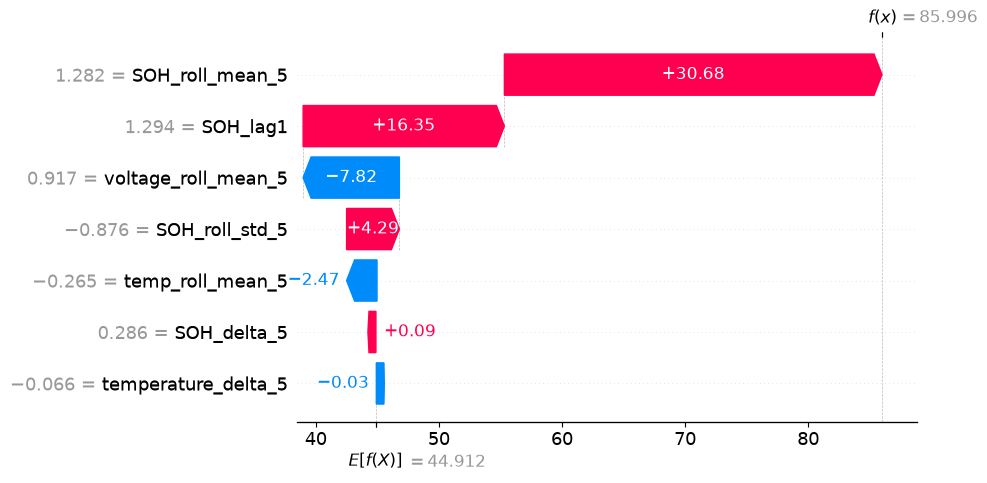


Worst optimistic | B0006 | Cycle 8 | Actual RUL = 53.0 | Predicted RUL = 89.5


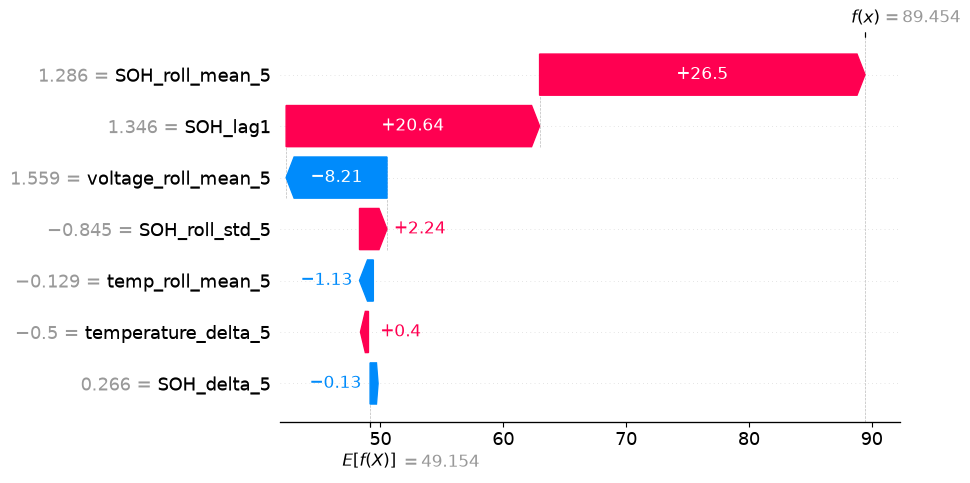


Worst conservative in-domain | B0007 | Cycle 41 | Actual RUL = 83.0 | Predicted RUL = 59.3


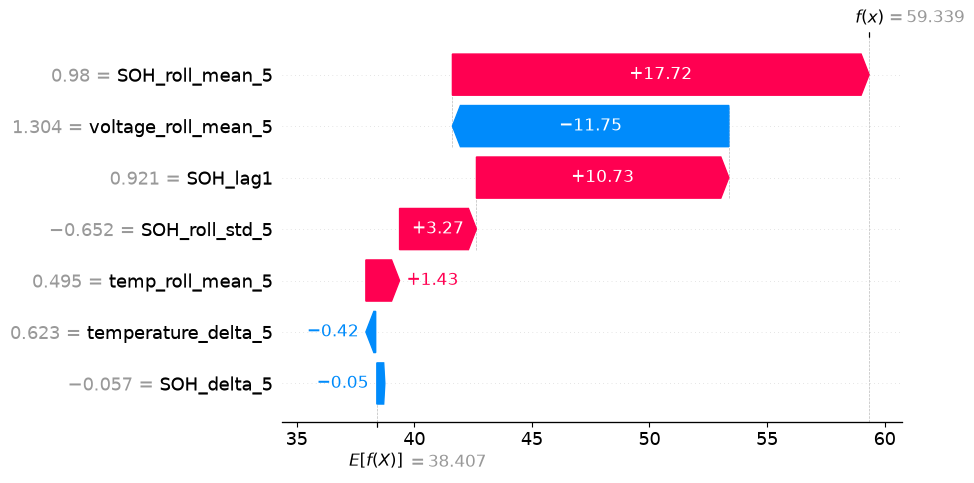


B0007 target-OOD | B0007 | Cycle 20 | Actual RUL = 104.0 | Predicted RUL = 72.9


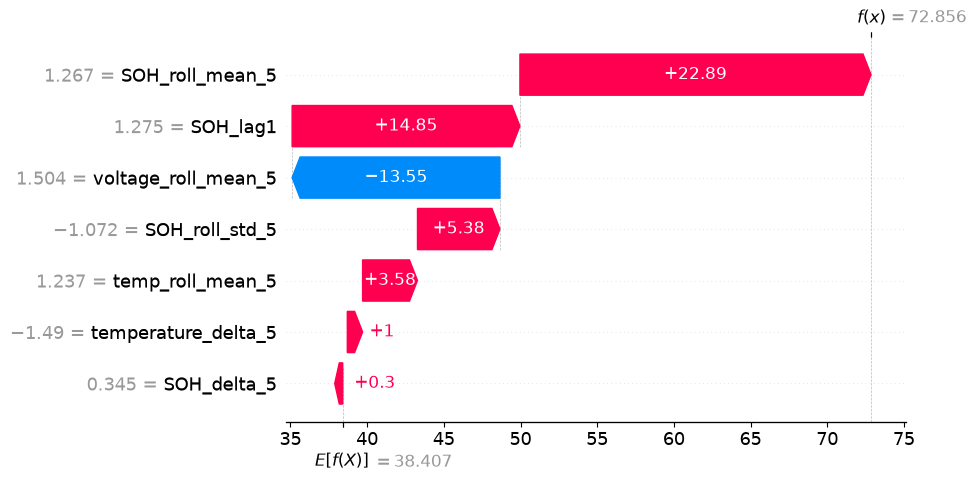

In [31]:
# ---------------------------------------------------------
# SHAP waterfall plots for forensic cases
# ---------------------------------------------------------

for _, case_row in forensic_cases.iterrows():

    case_name = case_row["case"]
    battery_name = case_row["battery"]
    cycle = int(case_row["cycle"])

    result = shap_results[
        battery_name
    ]

    test_df = result[
        "test_df"
    ]

    shap_values = result[
        "shap_values"
    ]

    matching_indices = (
        test_df.index[
            test_df["cycle"] == cycle
        ]
        .tolist()
    )

    if len(matching_indices) != 1:
        raise ValueError(
            f"Expected one observation for "
            f"{battery_name}, cycle {cycle}."
        )

    idx = matching_indices[0]

    print(
        f"\n{case_name} | "
        f"{battery_name} | "
        f"Cycle {cycle} | "
        f"Actual RUL = "
        f"{case_row['RUL_cycles']:.1f} | "
        f"Predicted RUL = "
        f"{case_row['RUL_pred']:.1f}"
    )

    shap.plots.waterfall(
        shap_values[idx],
        max_display=len(
            causal_features
        ),
        show=True,
    )

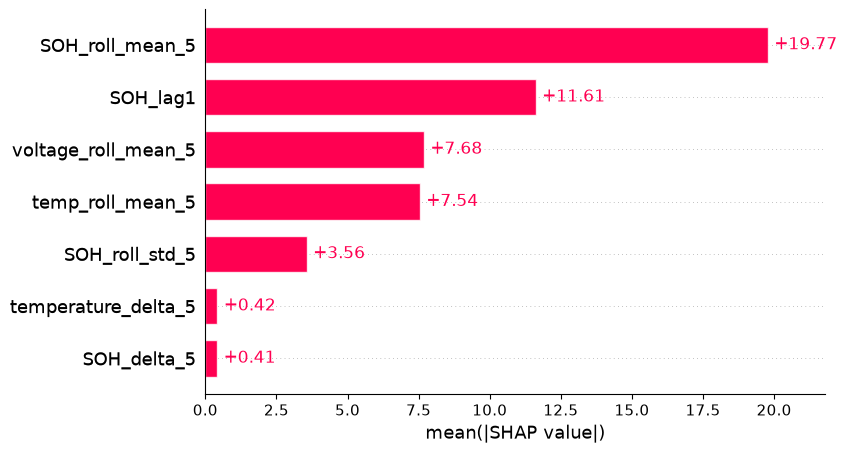

In [32]:
# ---------------------------------------------------------
# Aggregate LOBO SHAP explanation
# ---------------------------------------------------------

all_shap_values = np.vstack(
    [
        shap_results[
            battery_name
        ]["shap_values"].values
        for battery_name
        in battery_names
    ]
)

all_feature_values = np.vstack(
    [
        shap_results[
            battery_name
        ]["X_test_scaled"].values
        for battery_name
        in battery_names
    ]
)

all_base_values = np.concatenate(
    [
        np.asarray(
            shap_results[
                battery_name
            ][
                "shap_values"
            ].base_values
        ).reshape(-1)
        for battery_name
        in battery_names
    ]
)


combined_shap = shap.Explanation(
    values=all_shap_values,
    base_values=all_base_values,
    data=all_feature_values,
    feature_names=causal_features,
)


shap.plots.bar(
    combined_shap,
    max_display=len(
        causal_features
    ),
    show=True,
)

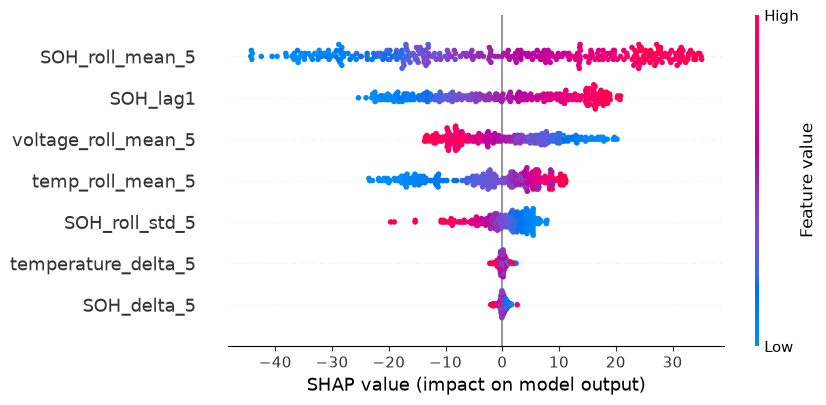

In [33]:
shap.plots.beeswarm(
    combined_shap,
    max_display=len(
        causal_features
    ),
    show=True,
)

In [34]:
def enforce_monotonic_rul(predictions):
    """
    Enforce two physical constraints on sequential RUL predictions:

    1. RUL cannot be negative.
    2. Predicted RUL cannot increase as discharge cycles progress.

    This is post-processing, not model training.
    """

    predictions = np.asarray(
        predictions,
        dtype=float,
    )

    nonnegative = np.clip(
        predictions,
        0,
        None,
    )

    monotonic = np.minimum.accumulate(
        nonnegative
    )

    return monotonic

## Physics-Informed RUL Post-Processing

Raw regression predictions are not guaranteed to satisfy physical
constraints expected of remaining useful life.

Two constraints are therefore evaluated:

\[
RUL_t \ge 0
\]

and

\[
RUL_{t+1} \le RUL_t
\]

for sequential discharge observations.

A running-minimum transformation is applied after clipping predictions
at zero.

This transformation is strictly a post-processing constraint. It does
not improve the underlying model fit and must therefore be evaluated
separately from raw model performance.

A potential limitation is that an erroneously low early prediction can
propagate forward through the running-minimum constraint.

In [35]:
# ---------------------------------------------------------
# LOBO physics-informed post-processing
# ---------------------------------------------------------

postprocess_records = []
postprocessed_predictions = {}


for battery_name in battery_names:

    raw_df = model_predictions[
        (
            battery_name,
            "Linear",
        )
    ].copy()

    raw_df = (
        raw_df
        .sort_values("cycle")
        .reset_index(drop=True)
    )

    actual = raw_df[
        "RUL_cycles"
    ].to_numpy()

    raw_pred = raw_df[
        "RUL_pred"
    ].to_numpy()

    nonnegative_pred = np.clip(
        raw_pred,
        0,
        None,
    )

    monotonic_pred = enforce_monotonic_rul(
        raw_pred
    )

    prediction_versions = {
        "Raw":
            raw_pred,

        "Non-negative":
            nonnegative_pred,

        "Monotonic":
            monotonic_pred,
    }

    for version, pred in prediction_versions.items():

        metrics = regression_metrics(
            actual,
            pred,
        )

        violations = np.sum(
            np.diff(pred) > 0
        )

        postprocess_records.append(
            {
                "battery":
                    battery_name,

                "prediction":
                    version,

                **metrics,

                "monotonicity_violations":
                    violations,

                "min_prediction":
                    pred.min(),

                "max_prediction":
                    pred.max(),
            }
        )

    result_df = raw_df[
        [
            "battery",
            "cycle",
            "RUL_cycles",
        ]
    ].copy()

    result_df[
        "RUL_raw"
    ] = raw_pred

    result_df[
        "RUL_nonnegative"
    ] = nonnegative_pred

    result_df[
        "RUL_monotonic"
    ] = monotonic_pred

    postprocessed_predictions[
        battery_name
    ] = result_df


postprocess_summary = pd.DataFrame(
    postprocess_records
)


display(
    postprocess_summary.round(4)
)

,battery,prediction,MAE,RMSE,R2,Bias,monotonicity_violations,min_prediction,max_prediction
0,B0005,Raw,6.6654,8.2103,0.9084,6.0755,25,3.6740,100.2733
1,B0005,Non-negative,6.6654,8.2103,0.9084,6.0755,25,3.6740,100.2733
2,B0005,Monotonic,5.4003,6.6540,0.9399,4.7381,0,3.6740,99.2672
3,B0006,Raw,9.1719,12.6535,0.3409,8.6571,11,1.6107,90.2507
4,B0006,Non-negative,9.1719,12.6535,0.3409,8.6571,11,1.6107,90.2507
5,B0006,Monotonic,7.9710,11.8487,0.4221,7.0946,0,1.6107,90.2507
6,B0007,Raw,15.1887,16.8842,0.7501,-13.1471,37,12.8408,99.4717
7,B0007,Non-negative,15.1887,16.8842,0.7501,-13.1471,37,12.8408,99.4717
8,B0007,Monotonic,16.0152,17.7021,0.7253,-14.4147,0,12.8408,99.4717
9,B0018,Raw,9.9801,11.3469,0.6658,-4.8778,15,-14.0087,91.2621


In [36]:
# ---------------------------------------------------------
# Raw versus monotonic performance change
# ---------------------------------------------------------

postprocess_comparison = []


for battery_name in battery_names:

    battery_results = (
        postprocess_summary.loc[
            postprocess_summary[
                "battery"
            ] == battery_name
        ]
        .set_index(
            "prediction"
        )
    )

    raw = battery_results.loc[
        "Raw"
    ]

    monotonic = battery_results.loc[
        "Monotonic"
    ]

    postprocess_comparison.append(
        {
            "battery":
                battery_name,

            "raw_MAE":
                raw["MAE"],

            "monotonic_MAE":
                monotonic["MAE"],

            "MAE_change":
                monotonic["MAE"]
                - raw["MAE"],

            "MAE_change_percent":
                100
                * (
                    monotonic["MAE"]
                    - raw["MAE"]
                )
                / raw["MAE"],

            "raw_RMSE":
                raw["RMSE"],

            "monotonic_RMSE":
                monotonic["RMSE"],

            "raw_R2":
                raw["R2"],

            "monotonic_R2":
                monotonic["R2"],

            "raw_bias":
                raw["Bias"],

            "monotonic_bias":
                monotonic["Bias"],

            "violations_before":
                int(
                    raw[
                        "monotonicity_violations"
                    ]
                ),

            "violations_after":
                int(
                    monotonic[
                        "monotonicity_violations"
                    ]
                ),
        }
    )


postprocess_comparison = pd.DataFrame(
    postprocess_comparison
)


display(
    postprocess_comparison.round(4)
)

,battery,raw_MAE,monotonic_MAE,MAE_change,MAE_change_percent,raw_RMSE,monotonic_RMSE,raw_R2,monotonic_R2,raw_bias,monotonic_bias,violations_before,violations_after
0,B0005,6.6654,5.4003,-1.2651,-18.9797,8.2103,6.6540,0.9084,0.9399,6.0755,4.7381,25,0
1,B0006,9.1719,7.9710,-1.2009,-13.0931,12.6535,11.8487,0.3409,0.4221,8.6571,7.0946,11,0
2,B0007,15.1887,16.0152,0.8264,5.4411,16.8842,17.7021,0.7501,0.7253,-13.1471,-14.4147,37,0
3,B0018,9.9801,10.0216,0.0415,0.4162,11.3469,11.0579,0.6658,0.6826,-4.8778,-5.1631,15,0


### Interpretation of Physics-Informed Constraints

The monotonic running-minimum constraint eliminates all sequential RUL
increases, but its predictive benefit is not consistent across held-out
batteries.

It improves MAE for B0005 and B0006 by approximately 19% and 13%,
respectively, but degrades B0007 by approximately 5% and provides
essentially no MAE improvement for B0018.

This demonstrates an important distinction between physical consistency
and predictive accuracy. A monotonically decreasing RUL trajectory appears
physically plausible, but a running-minimum transformation can propagate an
erroneously low prediction through all subsequent cycles.

The monotonic constraint is therefore retained as an experimental
diagnostic rather than adopted as the default production transformation.

Non-negative clipping is more defensible as a hard output constraint because
negative remaining useful life is physically undefined. It leaves B0005,
B0006, and B0007 unchanged and improves B0018, where the raw Linear model
produces negative late-life predictions.

Accordingly, the proposed reporting constraint is:

\[
RUL_{\mathrm{reported}} = \max(0, RUL_{\mathrm{raw}})
\]

while raw model predictions remain available for validation, residual
analysis, and model monitoring.

## Multi-Battery SOH Generalization

RUL prediction combines current degradation state with the battery-specific
mapping between that state and future lifetime. SOH estimation is a narrower
problem: estimating the current health state from historical degradation
measurements.

To separate these tasks, SOH prediction is evaluated independently using
leave-one-battery-out validation.

The same causal feature principle is maintained. Current-cycle SOH,
current-cycle capacity, discharge-cycle number, and battery identity are
excluded from the predictors.

In [37]:
# ---------------------------------------------------------
# Build multi-battery SOH datasets
# ---------------------------------------------------------

soh_datasets = {}


for battery_name in battery_names:

    df = (
        battery_models[
            battery_name
        ]
        .copy()
    )

    soh_df = (
        df[
            [
                "cycle",
                "SOH_percent",
                *causal_features,
            ]
        ]
        .dropna()
        .reset_index(drop=True)
    )

    soh_df[
        "battery"
    ] = battery_name

    soh_datasets[
        battery_name
    ] = soh_df

    print(
        f"{battery_name}: "
        f"{len(soh_df)} observations | "
        f"cycles "
        f"{soh_df['cycle'].min()}-"
        f"{soh_df['cycle'].max()} | "
        f"SOH "
        f"{soh_df['SOH_percent'].min():.2f}-"
        f"{soh_df['SOH_percent'].max():.2f}%"
    )

B0005: 162 observations | cycles 7-168 | SOH 69.35-99.75%
B0006: 162 observations | cycles 7-168 | SOH 56.69-98.91%
B0007: 162 observations | cycles 7-168 | SOH 74.06-99.60%
B0018: 126 observations | cycles 7-132 | SOH 72.29-98.28%


In [38]:
# ---------------------------------------------------------
# LOBO SOH validation
# ---------------------------------------------------------

soh_lobo_records = []
soh_lobo_predictions = {}


for held_out_battery in battery_names:

    training_batteries = [
        name
        for name in battery_names
        if name != held_out_battery
    ]

    train_df = pd.concat(
        [
            soh_datasets[name]
            for name in training_batteries
        ],
        ignore_index=True,
    )

    test_df = (
        soh_datasets[
            held_out_battery
        ]
        .copy()
        .reset_index(drop=True)
    )

    X_train = train_df[
        causal_features
    ]

    y_train = train_df[
        "SOH_percent"
    ]

    X_test = test_df[
        causal_features
    ]

    y_test = test_df[
        "SOH_percent"
    ]

    models = {
        "Linear":
            Pipeline(
                [
                    (
                        "scaler",
                        StandardScaler(),
                    ),
                    (
                        "model",
                        LinearRegression(),
                    ),
                ]
            ),

        "Ridge":
            Pipeline(
                [
                    (
                        "scaler",
                        StandardScaler(),
                    ),
                    (
                        "model",
                        Ridge(
                            alpha=1.0
                        ),
                    ),
                ]
            ),
    }


    for model_name, model in models.items():

        model.fit(
            X_train,
            y_train,
        )

        pred = model.predict(
            X_test
        )

        metrics = regression_metrics(
            y_test,
            pred,
        )

        soh_lobo_records.append(
            {
                "held_out_battery":
                    held_out_battery,

                "model":
                    model_name,

                "train_observations":
                    len(train_df),

                "test_observations":
                    len(test_df),

                **metrics,
            }
        )

        prediction_df = test_df[
            [
                "battery",
                "cycle",
                "SOH_percent",
            ]
        ].copy()

        prediction_df[
            "SOH_pred"
        ] = pred

        prediction_df[
            "error"
        ] = (
            pred
            -
            y_test.to_numpy()
        )

        prediction_df[
            "abs_error"
        ] = np.abs(
            prediction_df[
                "error"
            ]
        )

        soh_lobo_predictions[
            (
                held_out_battery,
                model_name,
            )
        ] = prediction_df


soh_lobo_summary = pd.DataFrame(
    soh_lobo_records
)


display(
    soh_lobo_summary.round(4)
)

,held_out_battery,model,train_observations,test_observations,MAE,RMSE,R2,Bias
0,B0005,Linear,450,162,0.3531,0.6607,0.9957,-0.0028
1,B0005,Ridge,450,162,0.3850,0.6702,0.9955,0.0378
2,B0006,Linear,450,162,0.6223,1.1045,0.9911,0.1111
3,B0006,Ridge,450,162,0.6058,1.1129,0.9910,0.0548
4,B0007,Linear,450,162,0.3141,0.6143,0.9945,-0.0946
5,B0007,Ridge,450,162,0.3107,0.6196,0.9944,-0.1302
6,B0018,Linear,486,126,0.6828,1.1986,0.9765,0.0166
7,B0018,Ridge,486,126,0.7114,1.2121,0.9759,0.0468


In [39]:
# ---------------------------------------------------------
# Aggregate SOH generalization performance
# ---------------------------------------------------------

soh_aggregate_records = []


for model_name in [
    "Linear",
    "Ridge",
]:

    rows = (
        soh_lobo_summary.loc[
            soh_lobo_summary[
                "model"
            ] == model_name
        ]
    )

    pooled = pd.concat(
        [
            soh_lobo_predictions[
                (
                    battery_name,
                    model_name,
                )
            ]
            for battery_name
            in battery_names
        ],
        ignore_index=True,
    )

    pooled_metrics = regression_metrics(
        pooled[
            "SOH_percent"
        ],
        pooled[
            "SOH_pred"
        ],
    )

    soh_aggregate_records.append(
        {
            "model":
                model_name,

            "Macro_MAE":
                rows[
                    "MAE"
                ].mean(),

            "Macro_RMSE":
                rows[
                    "RMSE"
                ].mean(),

            "Macro_R2":
                rows[
                    "R2"
                ].mean(),

            "Macro_abs_Bias":
                rows[
                    "Bias"
                ].abs().mean(),

            "Pooled_MAE":
                pooled_metrics[
                    "MAE"
                ],

            "Pooled_RMSE":
                pooled_metrics[
                    "RMSE"
                ],

            "Pooled_R2":
                pooled_metrics[
                    "R2"
                ],

            "Pooled_Bias":
                pooled_metrics[
                    "Bias"
                ],
        }
    )


soh_aggregate_summary = pd.DataFrame(
    soh_aggregate_records
)


display(
    soh_aggregate_summary.round(4)
)

,model,Macro_MAE,Macro_RMSE,Macro_R2,Macro_abs_Bias,Pooled_MAE,Pooled_RMSE,Pooled_R2,Pooled_Bias
0,Linear,0.4931,0.8945,0.9894,0.0563,0.4819,0.9133,0.9926,0.0070
1,Ridge,0.5032,0.9037,0.9892,0.0674,0.4910,0.9224,0.9925,-0.0003


### SOH versus RUL Generalization

Leave-one-battery-out validation reveals a substantial difference between
current-state estimation and future-life prediction.

The Linear SOH model achieves:

- Macro MAE: 0.493 percentage points
- Macro RMSE: 0.895 percentage points
- Macro R²: 0.989
- Pooled MAE: 0.482 percentage points
- Pooled R²: 0.993
- Pooled bias: +0.007 percentage points

Performance remains strong for every held-out battery, including B0018,
which produces the largest Linear-model SOH MAE of approximately
0.68 percentage points.

In contrast, cross-battery RUL errors are substantially larger and strongly
battery dependent.

This distinction is physically and statistically important.

SOH estimation primarily asks:

> Given recent degradation measurements, what is the battery's current
> health state?

RUL prediction asks a more difficult question:

> Given the current degradation state, how much future operating life
> remains before the EOL criterion is reached?

The latter requires knowledge of the future degradation trajectory.

Therefore, two cells can exhibit similar current health indicators while
having different future lifetimes because their subsequent degradation
rates and degradation regimes differ.

The results suggest that current health state is comparatively transferable
across the evaluated NASA cells, whereas the mapping from health state to
remaining lifetime is substantially more cell dependent.

This finding also explains why high SOH-estimation accuracy should not be
interpreted as evidence that RUL prediction is equally reliable.

# Conclusions

This notebook evaluated whether battery SOH and RUL models developed from
individual NASA ageing cells generalize to completely unseen batteries.

## 1. Battery lifetime is strongly cell dependent

Using the first measured discharge cycle at or below 80% SOH as the EOL
criterion, the four evaluated cells reach EOL at substantially different
discharge-cycle counts:

- B0005: cycle 101
- B0006: cycle 61
- B0007: cycle 124
- B0018: cycle 75

The observed EOL spread is therefore 63 discharge cycles.

This variation demonstrates that discharge-cycle count alone is not a
transferable representation of battery health or remaining lifetime.

## 2. SOH generalizes substantially better than RUL

Leave-one-battery-out SOH estimation performs strongly across all four
held-out cells.

The Linear model achieves a pooled MAE of approximately 0.48 SOH
percentage points and pooled R² of approximately 0.993.

RUL prediction is substantially more difficult.

Under the same battery-level validation philosophy, the Linear RUL model
achieves a macro MAE of approximately 10.25 discharge cycles and pooled
R² of approximately 0.803, with large battery-specific biases.

This establishes an important distinction:

\[
\text{estimating current health}
\neq
\text{predicting future lifetime}
\]

A model can estimate the current degradation state accurately without
knowing how quickly a particular cell will degrade in the future.

## 3. Linear Regression provides the strongest overall RUL benchmark

Across the evaluated LOBO folds, Linear Regression slightly outperforms
Ridge Regression and materially outperforms Random Forest on aggregate
cross-battery RUL metrics.

Random Forest performs particularly poorly when the held-out degradation
trajectory requires extrapolation beyond relationships represented by the
training batteries.

The result reinforces that greater model complexity does not automatically
improve prognostic generalization.

## 4. Target-range extrapolation explains only part of the transfer error

B0007 contains true RUL observations beyond the maximum RUL represented by
its training batteries and exhibits substantial conservative prediction
bias.

However, substantial error remains even for B0007 observations inside the
training target range.

B0006 also exhibits large optimistic errors despite remaining within the
training RUL range.

Therefore, target-range extrapolation is an important failure mode but is
not a complete explanation of cross-cell prediction error.

The results indicate battery-specific degradation-to-lifetime mapping
differences.

## 5. Simple feature-space OOD metrics are insufficient confidence measures

Univariate training-range checks and multivariate standardized feature
distance were evaluated as possible indicators of unreliable predictions.

Neither diagnostic produced a consistent monotonic relationship with RUL
error across the four batteries.

A held-out observation can therefore appear geometrically close to the
training feature distribution while still follow a different future
degradation trajectory.

Prediction reliability depends on more than feature-space proximity.

## 6. SHAP identifies recent health history as the dominant predictive signal

Cross-validated SHAP analysis shows that the model relies primarily on
recent historical SOH information.

The strongest global predictors are:

1. rolling historical SOH;
2. previous-cycle SOH;
3. historical temperature and voltage behaviour;
4. short-term SOH variability.

Short-term SOH and temperature delta features contribute comparatively
little and exhibit less stable behaviour across folds.

SHAP additivity was verified numerically to floating-point precision.

However, SHAP explains how the fitted model constructs a prediction; it
does not establish physical causality or guarantee predictive validity.

## 7. Local explanations expose cross-cell calibration failure

For B0005, the model can map degradation state to future lifetime with
near-zero prediction error for selected observations.

For B0006, apparently healthy historical SOH produces a severe optimistic
RUL prediction even though the true target lies inside the training RUL
range.

For B0007, the model substantially underestimates remaining life, including
for observations that remain inside the training target range.

These examples demonstrate that similar measured degradation states can
correspond to different future lifetimes across cells.

## 8. Physical consistency does not automatically improve accuracy

Non-negative clipping is retained as a defensible reporting constraint
because negative RUL is physically undefined.

A monotonic running-minimum RUL constraint removes all sequential increases
but does not improve predictive accuracy consistently across held-out
batteries.

It improves B0005 and B0006 but degrades B0007 and provides little MAE
benefit for B0018.

The monotonic transformation is therefore retained as an experimental
diagnostic rather than adopted as the default production estimator.

## 9. Proposed production direction

The evidence from this notebook supports the following architecture:

\[
\text{validated telemetry}
\rightarrow
\text{causal feature engineering}
\rightarrow
\text{SOH estimation}
\rightarrow
\text{RUL model}
\rightarrow
\text{non-negative output constraint}
\rightarrow
\text{validation / monitoring layer}
\]

Raw predictions should remain available for residual analysis, monitoring,
and model validation.

Prediction confidence should not be inferred solely from simple geometric
feature-distance measures.

## Limitations

The conclusions are limited to four cells from the NASA Li-ion ageing
dataset and should not be interpreted as population-level battery
generalization.

Additional limitations include:

- a fixed 80% SOH EOL definition;
- limited cell population size;
- laboratory ageing rather than field fleet operation;
- battery-specific lifetime variation;
- correlated degradation predictors;
- limited operational and environmental telemetry;
- no prospective prediction on a truly future deployment population;
- no validated probabilistic uncertainty model for nonstationary
  late-life degradation.

Accordingly, this notebook demonstrates rigorous cross-cell validation and
failure analysis rather than claiming deployment-ready universal RUL
prediction.